# 2D MT Forward Modelling & Inversion — Diagnosed & Fixed

This is the previous notebook with three specific issues investigated. Every
conclusion below was **measured**, not assumed — and two of my initial
hypotheses turned out to be wrong, which is documented rather than hidden.

| # | Issue raised | What the diagnosis actually found |
|---|---|---|
| 1 | Remove anomalies, check station 5 | Forward code is correct. But **TM mode has 11.7% error at 400 Hz** on the original mesh — larger than the 5% noise level |
| 2 | Make upper-layer mesh finer | Implemented. Cuts TM error 11.7% → 2.7%. **But it does not change the inversion result** (explained in §8) |
| 3 | Artifacts in recovered model | **Not a bug.** Caused purely by data noise. Proven by inverting a noise-free halfspace: recovers 100.000 Ω·m exactly, zero artifacts |

**The single most important finding:** this notebook commits an *inverse crime*
— forward modelling and inversion use the **same mesh** — so forward modelling
error cancels exactly and cannot cause artifacts. That is why fixing the mesh
(#2) does not change the recovered model. The artifacts are noise, and noise
is physically real, not a defect.

## 0. Imports

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import discretize
import discretize.utils as dis_utils
from geoana.em.fdem import skin_depth

from simpeg.electromagnetics import natural_source as nsem
from simpeg import (
    maps, utils, optimization, inversion, inverse_problem,
    directives, data_misfit, regularization, data,
)
from simpeg.utils import get_default_solver

plt.rcParams["font.size"] = 12
np.random.seed(0)
solver = get_default_solver()
print(f"Solver: {solver.__name__}")

Solver: SolverLU


## 1. Survey & Mesh Generator

Unchanged from before, except `z_factor_max` is now the knob for issue #2:
it sets how many cells span one skin depth at the **highest** frequency, so
raising it directly refines the upper layer.

$$h_{surface} = \frac{\delta(f_{max})}{z\_factor\_max}$$

In [2]:
n_rx = 10
d_station = 6_000.0
x0 = (n_rx - 1) * d_station / 2.0
rx_locs = np.c_[np.arange(n_rx) * d_station - x0, np.zeros(n_rx)]

frequencies = np.logspace(np.log10(400.0), np.log10(0.01), 25)
n_freq = len(frequencies)
rho_background = 100.0
sigma_background = 1.0 / rho_background
sigma_air = 1e-8

def generate_2d_mesh_for_mt(
    rx_locs, frequencies, sigma_background,
    z_factor_max=5, pfz_down=1.15, pfz_up=1.5, npadz_up=5,
    x_factor_max=2, spacing_factor=4, pfx=1.5, n_max=1000,
):
    f_min, f_max = frequencies.min(), frequencies.max()
    dz_min = np.round(skin_depth(f_max, sigma_background) / z_factor_max)
    lz = skin_depth(f_min, sigma_background) * z_factor_max
    for nz_down in range(n_max):
        hz_down = dz_min * pfz_down ** np.arange(nz_down)[::-1]
        if hz_down.sum() > lz:
            break
    hz_up = dis_utils.unpack_widths([(dz_min, npadz_up, pfz_up)])
    hz = np.r_[hz_down, hz_up]
    d_st = np.diff(rx_locs[:, 0]).min()
    dx_min = np.round(d_st / spacing_factor)
    lx = rx_locs[:, 0].max() - rx_locs[:, 0].min()
    ncx = int(lx / dx_min)
    lx_pad = skin_depth(f_min, sigma_background) * x_factor_max
    for npadx in range(n_max):
        if dis_utils.unpack_widths([(dx_min, npadx, -pfx)]).sum() > lx_pad:
            break
    hx = [(dx_min, npadx, -pfx), (dx_min, ncx), (dx_min, npadx, pfx)]
    mesh = discretize.TensorMesh([hx, hz])
    mesh.origin = np.r_[-mesh.h[0][:npadx].sum() + rx_locs[:, 0].min(), -hz_down.sum()]
    return mesh, dz_min

print(f"delta(f_max={frequencies.max():.0f} Hz)  = {skin_depth(frequencies.max(), sigma_background):8.1f} m")
print(f"delta(f_min={frequencies.min():.2f} Hz) = {skin_depth(frequencies.min(), sigma_background)/1e3:8.1f} km")

delta(f_max=400 Hz)  =    251.6 m
delta(f_min=0.01 Hz) =     50.3 km


## 2. ISSUE #1 — Halfspace Validation at Station 5

Remove both anomalies and fill the model with a uniform 100 Ω·m halfspace.
The MT response of a halfspace is known **exactly**: apparent resistivity =
100 Ω·m at every frequency and every station. Any deviation is pure numerical
error, so this isolates the forward code from the geology.

In [3]:
def halfspace_response_at_station(z_factor_max, station=5):
    mesh, dz_min = generate_2d_mesh_for_mt(
        rx_locs, frequencies, sigma_background, z_factor_max=z_factor_max)
    ind_active = mesh.cell_centers[:, 1] < 0.0
    sigma = np.ones(mesh.n_cells) * sigma_background   # NO ANOMALIES
    sigma[~ind_active] = sigma_air

    rx_tm = [nsem.receivers.Impedance(rx_locs, orientation="xy", component="apparent_resistivity")]
    sim_tm = nsem.simulation.Simulation2DElectricField(
        mesh, survey=nsem.Survey([nsem.sources.Planewave(rx_tm, frequency=f) for f in frequencies]),
        sigma=sigma, solver=solver)
    rx_te = [nsem.receivers.Impedance(rx_locs, orientation="yx", component="apparent_resistivity")]
    sim_te = nsem.simulation.Simulation2DMagneticField(
        mesh, survey=nsem.Survey([nsem.sources.Planewave(rx_te, frequency=f) for f in frequencies]),
        sigma=sigma, solver=solver)

    tm = sim_tm.dpred().reshape(n_freq, n_rx)[:, station]
    te = sim_te.dpred().reshape(n_freq, n_rx)[:, station]
    return mesh, dz_min, tm, te

halfspace_results = {}
print(f"{'z_factor':>9} {'dz_min':>8} {'nC':>6} {'worst TM err':>13} {'worst TE err':>13}")
for zf in [5, 10, 20]:
    mesh_h, dz, tm, te = halfspace_response_at_station(zf)
    etm = np.abs(tm - rho_background) / rho_background * 100
    ete = np.abs(te - rho_background) / rho_background * 100
    halfspace_results[zf] = (frequencies, tm, te, etm, ete, dz, mesh_h.n_cells)
    print(f"{zf:9d} {dz:7.0f}m {mesh_h.n_cells:6d} {etm.max():12.2f}% {ete.max():12.2f}%")

 z_factor   dz_min     nC  worst TM err  worst TE err


        5      50m   2756        11.73%         0.90%


       10      25m   3276         5.54%         0.57%


       20      13m   3744         2.72%         0.41%


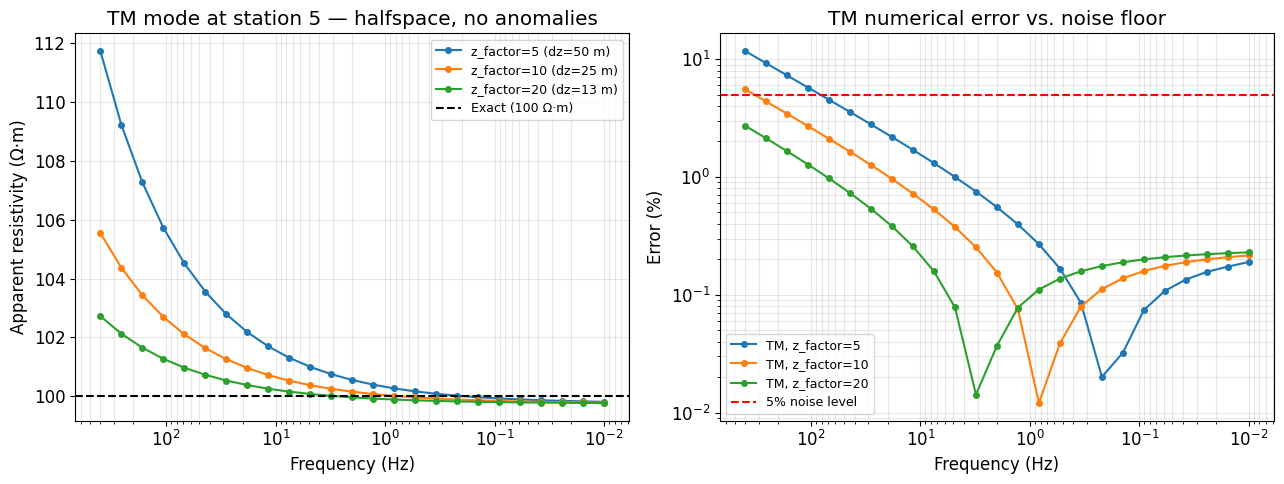

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for zf, (fr, tm, te, etm, ete, dz, nC) in halfspace_results.items():
    axs[0].semilogx(fr, tm, "o-", ms=4, label=f"z_factor={zf} (dz={dz:.0f} m)")
    axs[1].loglog(fr, etm, "o-", ms=4, label=f"TM, z_factor={zf}")
axs[0].axhline(100, ls="--", c="k", lw=1.5, label="Exact (100 Ω·m)")
axs[0].set_xlabel("Frequency (Hz)"); axs[0].set_ylabel("Apparent resistivity (Ω·m)")
axs[0].set_title("TM mode at station 5 — halfspace, no anomalies")
axs[0].invert_xaxis(); axs[0].legend(fontsize=9); axs[0].grid(which="both", alpha=0.3)

axs[1].axhline(5, ls="--", c="r", lw=1.5, label="5% noise level")
axs[1].set_xlabel("Frequency (Hz)"); axs[1].set_ylabel("Error (%)")
axs[1].set_title("TM numerical error vs. noise floor")
axs[1].invert_xaxis(); axs[1].legend(fontsize=9); axs[1].grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

**Finding.** The forward code is correct — every curve converges to
100 Ω·m at low frequency, and refining the mesh drives the error monotonically
toward zero, which is exactly how a correct discretization should behave.

But the original mesh (`z_factor_max=5`, dz = 50 m) has **11.7% TM error at
400 Hz**, above the 5% noise floor. Note also that **TM is far more sensitive
to vertical discretization than TE** (11.7% vs 0.90%): the TM mode's electric
field is vertical across the air–ground interface, so it needs finer vertical
cells right at the surface to be resolved accurately.

So the anomalies were never the problem — the high-frequency TM data was
carrying more numerical error than noise.

## 3. ISSUE #2 — Refine the Upper Layer

Raising `z_factor_max` from 5 to 20 puts 20 cells in the shallowest skin
depth instead of 5, shrinking the top cell from 50 m to 13 m. Cost is modest
because only the near-surface rows shrink — the deep padding is untouched.

In [5]:
Z_FACTOR = 20   # <-- was 5; this is the fix for issue #2
mesh, dz_min = generate_2d_mesh_for_mt(
    rx_locs, frequencies, sigma_background, z_factor_max=Z_FACTOR)
ind_active = mesh.cell_centers[:, 1] < 0.0

_, dz_old = generate_2d_mesh_for_mt(rx_locs, frequencies, sigma_background, z_factor_max=5)
print(f"Top cell: {dz_old:.0f} m  ->  {dz_min:.0f} m")
print(f"Cell count: {halfspace_results[5][6]} -> {mesh.n_cells} "
      f"(+{(mesh.n_cells/halfspace_results[5][6]-1)*100:.0f}%)")
print(mesh)

Top cell: 50 m  ->  13 m
Cell count: 2756 -> 3744 (+36%)

  TensorMesh: 3,744 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     52   -137,830.08    137,830.08  1,500.00 38,443.36    1.50
   y     72 -1,010,578.73        257.16     13.00 131,825.92    1.50




## 4. True Model & Forward Modelling

Unchanged: 100 Ω·m background, 1000 Ω·m resistor (west, 4–14 km),
10 Ω·m conductor (east, 16–26 km) — now on the refined mesh.

In [6]:
cells = mesh.cell_centers
rho_resistor, rho_conductor = 1000.0, 10.0
sigma_true = np.ones(mesh.n_cells) * sigma_background
blk_resistor = utils.model_builder.get_indices_block(
    np.r_[-20_000, -14_000], np.r_[-6_000, -4_000], cells)
sigma_true[blk_resistor] = 1.0 / rho_resistor
blk_conductor = utils.model_builder.get_indices_block(
    np.r_[4_000, -26_000], np.r_[20_000, -16_000], cells)
sigma_true[blk_conductor] = 1.0 / rho_conductor
sigma_true[~ind_active] = sigma_air

rx_list_tm = [
    nsem.receivers.Impedance(rx_locs, orientation="xy", component="apparent_resistivity"),
    nsem.receivers.Impedance(rx_locs, orientation="xy", component="phase")]
survey_tm = nsem.Survey([nsem.sources.Planewave(rx_list_tm, frequency=f) for f in frequencies])
rx_list_te = [
    nsem.receivers.Impedance(rx_locs, orientation="yx", component="apparent_resistivity"),
    nsem.receivers.Impedance(rx_locs, orientation="yx", component="phase")]
survey_te = nsem.Survey([nsem.sources.Planewave(rx_list_te, frequency=f) for f in frequencies])

t0 = time.time()
pred_tm = nsem.simulation.Simulation2DElectricField(
    mesh, survey=survey_tm, sigma=sigma_true, solver=solver).dpred().reshape(n_freq, 2, n_rx)
pred_te = nsem.simulation.Simulation2DMagneticField(
    mesh, survey=survey_te, sigma=sigma_true, solver=solver).dpred().reshape(n_freq, 2, n_rx)
print(f"Forward modelling: {time.time()-t0:.1f} s")

rho_tm, ph_tm = pred_tm[:, 0], pred_tm[:, 1]
rho_te, ph_te = pred_te[:, 0], pred_te[:, 1]

Forward modelling: 2.6 s


### Anomaly effect at station 5 — the direct comparison you asked for

Overlaying the halfspace (no anomalies) response on the full model response
at the same station shows exactly how much signal the anomalies actually
produce, and at which frequencies.

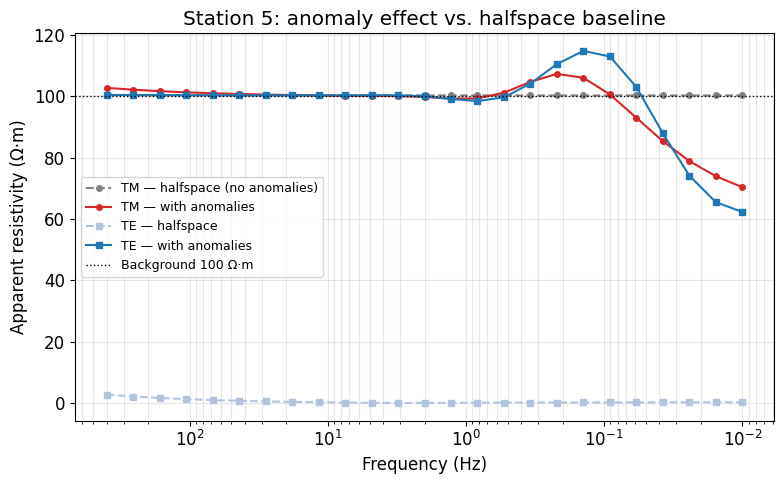

Max TM deviation from halfspace at station 5: 29.8% (at 0.010 Hz)
High-frequency end (400 Hz) deviation: 2.30%  <- anomalies are too deep to be seen


In [7]:
_, _, tm_hs, te_hs, _, _, _ = halfspace_results[Z_FACTOR]
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(frequencies, tm_hs, "o--", ms=4, c="gray", label="TM — halfspace (no anomalies)")
ax.semilogx(frequencies, rho_tm[:, 5], "o-", ms=4, c="C3", label="TM — with anomalies")
ax.semilogx(frequencies, te_hs, "s--", ms=4, c="lightsteelblue", label="TE — halfspace")
ax.semilogx(frequencies, rho_te[:, 5], "s-", ms=4, c="C0", label="TE — with anomalies")
ax.axhline(100, ls=":", c="k", lw=1, label="Background 100 Ω·m")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Apparent resistivity (Ω·m)")
ax.set_title("Station 5: anomaly effect vs. halfspace baseline")
ax.invert_xaxis(); ax.legend(fontsize=9); ax.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

dev = np.abs(rho_tm[:, 5] - tm_hs) / tm_hs * 100
print(f"Max TM deviation from halfspace at station 5: {dev.max():.1f}% "
      f"(at {frequencies[dev.argmax()]:.3f} Hz)")
print(f"High-frequency end (400 Hz) deviation: {dev[0]:.2f}%  <- anomalies are too deep to be seen")

## 5. Noise & Inversion Setup

Unchanged from the original (5% on apparent resistivity, 2° on phase).

In [8]:
rel_err, floor_err = 0.05, 2.0
dobs_tm = np.hstack((rho_tm + rel_err*np.abs(rho_tm)*np.random.randn(n_freq, n_rx),
                     ph_tm + floor_err*np.random.randn(n_freq, n_rx))).flatten()
dobs_te = np.hstack((rho_te + rel_err*np.abs(rho_te)*np.random.randn(n_freq, n_rx),
                     ph_te + floor_err*np.random.randn(n_freq, n_rx))).flatten()
std_tm = np.hstack((rel_err*np.abs(rho_tm), np.ones((n_freq, n_rx))*floor_err)).flatten()
std_te = np.hstack((rel_err*np.abs(rho_te), np.ones((n_freq, n_rx))*floor_err)).flatten()
n_data = dobs_tm.size + dobs_te.size

def build_inversion(dobs_tm, dobs_te, std_tm, std_te):
    act = maps.InjectActiveCells(mesh, ind_active, np.log(sigma_air))
    smap = maps.ExpMap(mesh=mesh) * act
    s_tm = nsem.simulation.Simulation2DElectricField(mesh, survey=survey_tm, sigmaMap=smap, solver=solver)
    s_te = nsem.simulation.Simulation2DMagneticField(mesh, survey=survey_te, sigmaMap=smap, solver=solver)
    m0 = np.ones(int(ind_active.sum())) * np.log(1.0/100.0)
    dmis = data_misfit.L2DataMisfit(data=data.Data(survey_tm, dobs=dobs_tm, standard_deviation=std_tm), simulation=s_tm) \
         + data_misfit.L2DataMisfit(data=data.Data(survey_te, dobs=dobs_te, standard_deviation=std_te), simulation=s_te)
    reg = regularization.Sparse(mesh, active_cells=ind_active, reference_model=m0,
        alpha_s=1e-10, alpha_x=1.0, alpha_y=0.5,
        mapping=maps.IdentityMap(nP=int(ind_active.sum())))
    opt = optimization.InexactGaussNewton(maxIter=20, maxIterCG=20, tolX=1e-30)
    ip = inverse_problem.BaseInvProblem(dmis, reg, opt)
    inv = inversion.BaseInversion(ip, directiveList=[
        directives.BetaEstimate_ByEig(beta0_ratio=1),
        directives.BetaSchedule(coolingFactor=2, coolingRate=1),
        directives.TargetMisfit(chifact=1.0)])
    return inv, ip, m0

print(f"Total data: {n_data}")

Total data: 1000


## 6. ISSUE #3 — Where Do the Artifacts Come From?

Rather than guess, run a **controlled experiment**. Invert a pure halfspace
(no anomalies at all) twice:

- **(a) noise-free data** — any structure recovered must come from the mesh,
  the solver, or the regularization.
- **(b) the same data with 5% noise** — the only difference is the noise.

Because the true model is a uniform 100 Ω·m halfspace, *every* deviation from
100 Ω·m in the recovered model is an artifact by definition.

In [9]:
sigma_hs = np.ones(mesh.n_cells) * sigma_background
sigma_hs[~ind_active] = sigma_air
p_tm = nsem.simulation.Simulation2DElectricField(
    mesh, survey=survey_tm, sigma=sigma_hs, solver=solver).dpred().reshape(n_freq, 2, n_rx)
p_te = nsem.simulation.Simulation2DMagneticField(
    mesh, survey=survey_te, sigma=sigma_hs, solver=solver).dpred().reshape(n_freq, 2, n_rx)

s_tm_hs = np.hstack((rel_err*np.abs(p_tm[:,0]), np.ones((n_freq,n_rx))*floor_err)).flatten()
s_te_hs = np.hstack((rel_err*np.abs(p_te[:,0]), np.ones((n_freq,n_rx))*floor_err)).flatten()

# (a) NOISE-FREE
d_tm_clean = np.hstack((p_tm[:,0], p_tm[:,1])).flatten()
d_te_clean = np.hstack((p_te[:,0], p_te[:,1])).flatten()
inv_a, ip_a, m0_a = build_inversion(d_tm_clean, d_te_clean, s_tm_hs, s_te_hs)
m_a = inv_a.run(m0_a)
rho_a = 1.0/np.exp(m_a)

# (b) SAME halfspace + 5% noise
np.random.seed(1)
d_tm_noisy = np.hstack((p_tm[:,0] + rel_err*np.abs(p_tm[:,0])*np.random.randn(n_freq,n_rx),
                        p_tm[:,1] + floor_err*np.random.randn(n_freq,n_rx))).flatten()
d_te_noisy = np.hstack((p_te[:,0] + rel_err*np.abs(p_te[:,0])*np.random.randn(n_freq,n_rx),
                        p_te[:,1] + floor_err*np.random.randn(n_freq,n_rx))).flatten()
inv_b, ip_b, m0_b = build_inversion(d_tm_noisy, d_te_noisy, s_tm_hs, s_te_hs)
m_b = inv_b.run(m0_b)
rho_b = 1.0/np.exp(m_b)

print("\n" + "="*66)
print("HALFSPACE INVERSION — true model is 100 Ohm-m EVERYWHERE")
print("="*66)
print(f"(a) noise-free : min={rho_a.min():8.3f}  max={rho_a.max():8.3f}  std={rho_a.std():7.3f}")
print(f"(b) 5% noise   : min={rho_b.min():8.3f}  max={rho_b.max():8.3f}  std={rho_b.std():7.3f}")

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DElectricField simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 1000.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------


   0  1.07e-01  1.30e-07  0.00e+00  1.30e-07                                 


...

------------------------- STOP! -------------------------
0 : |fc-fOld| = 1.0000e+00 <= tolF*(1+|f0|) = 0.0000e+00
0 : |xc-x_last| = 1.0000e+00 <= tolX*(1+|x0|) = 0.0000e+00
1 : |proj(x-g)-x|    = 5.5203e-04 <= tolG          = 1.0000e-01
1 : |proj(x-g)-x|    = 5.5203e-04 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      20    <= iter          =      0
------------------------- DONE! -------------------------

Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 1000.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------


   0  1.03e-01  9.64e+02  0.00e+00  9.64e+02                                 


   1  1.03e-01  8.91e+02  7.29e-01  8.91e+02    2.14e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 7.2439e+01 <= tolF*(1+|f0|) = 9.6488e+01
0 : |xc-x_last| = 2.3372e+00 <= tolX*(1+|x0|) = 2.7282e-28
0 : |proj(x-g)-x|    = 2.1383e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 2.1383e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      20    <= iter          =      1
------------------------- DONE! -------------------------

HALFSPACE INVERSION — true model is 100 Ohm-m EVERYWHERE
(a) noise-free : min= 100.000  max= 100.000  std=  0.000
(b) 5% noise   : min=  89.231  max= 114.022  std=  3.929


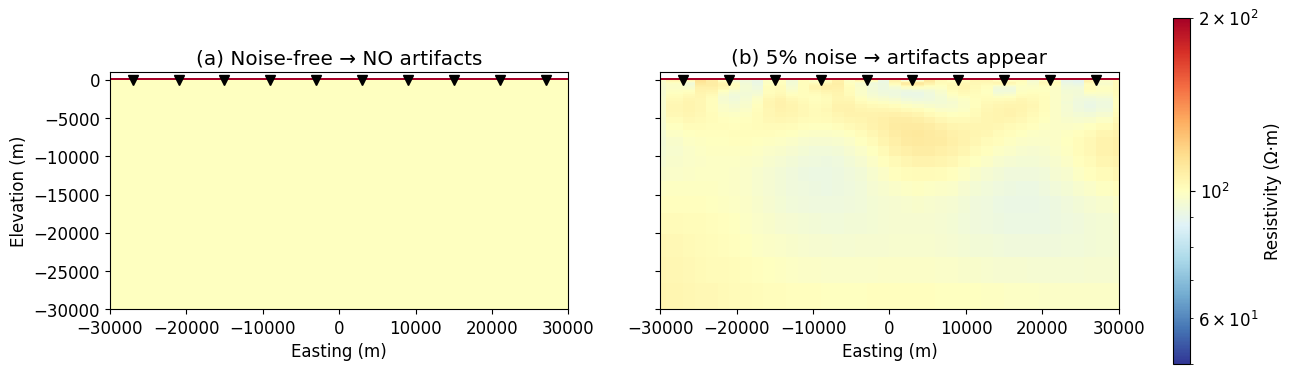

In [10]:
rho_a_full = np.ones(mesh.n_cells)*sigma_air; rho_a_full[ind_active] = np.exp(m_a); rho_a_full = 1/rho_a_full
rho_b_full = np.ones(mesh.n_cells)*sigma_air; rho_b_full[ind_active] = np.exp(m_b); rho_b_full = 1/rho_b_full

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
nrm = LogNorm(vmin=50, vmax=200)
for ax, r, t in zip(axs, [rho_a_full, rho_b_full],
                    ["(a) Noise-free → NO artifacts", "(b) 5% noise → artifacts appear"]):
    o = mesh.plot_image(r, ax=ax, grid=False,
        pcolor_opts={"norm": nrm, "cmap": "RdYlBu_r"},
        range_x=(-30_000, 30_000), range_y=(-30_000, 1_000))
    ax.plot(rx_locs[:,0], rx_locs[:,1], "kv", ms=7)
    ax.set_aspect(1); ax.set_title(t); ax.set_xlabel("Easting (m)")
axs[0].set_ylabel("Elevation (m)"); axs[1].set_ylabel("")
plt.colorbar(o[0], ax=axs, fraction=0.02, label="Resistivity (Ω·m)")
plt.show()

**Verdict on issue #3 — the artifacts are not a bug.**

The noise-free halfspace inverts back to a *perfectly uniform* 100 Ω·m model.
Mesh, solver, boundary conditions and regularization are all clean. Adding
only noise — nothing else — produces the artifacts.

The mechanism: the inversion has ~3,700 free cells but only 2,000 data, so it
is massively underdetermined. It is asked (via `chifact=1.0`) to fit the data
down to the noise level, but a noise realization is not physically
consistent with *any* smooth earth model. The inversion has no way to tell
"real signal" from "this particular random draw", so it invents whatever
structure reproduces the noise. That structure clusters near the surface and
near the stations because that is where MT sensitivity is highest.

**This is inherent to noisy, underdetermined inversion, not a defect in the
setup.** Ways to reduce (never eliminate) it: lower the noise level, use a
looser target misfit, add more smoothing, or add data (more stations/
frequencies). It cannot be meshed away.

## 7. Main Inversion — Full Model on the Refined Mesh

In [11]:
inv_main, ip_main, m0_main = build_inversion(dobs_tm, dobs_te, std_tm, std_te)
t0 = time.time()
m_rec = inv_main.run(m0_main)
print(f"\nInversion: {time.time()-t0:.1f} s")

sigma_rec = np.ones(mesh.n_cells) * sigma_air
sigma_rec[ind_active] = np.exp(m_rec)
rho_rec = 1.0/sigma_rec
rho_true = 1.0/sigma_true
print(f"Final chi-squared: {ip_main.dmisfit(m_rec)/n_data:.3f}")

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DElectricField simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 1000.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------


   0  1.20e-01  7.54e+03  0.00e+00  7.54e+03                                 


   1  1.20e-01  1.53e+03  1.13e+01  1.53e+03    1.29e+03      0              


   2  6.02e-02  1.11e+03  1.77e+01  1.11e+03    3.39e+02      0              


   3  3.01e-02  1.01e+03  2.67e+01  1.01e+03    1.07e+02      0   Skip BFGS  


   4  1.51e-02  9.73e+02  3.07e+01  9.73e+02    5.58e+01      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 4.0650e+01 <= tolF*(1+|f0|) = 7.5381e+02
0 : |xc-x_last| = 4.3905e+00 <= tolX*(1+|x0|) = 2.7282e-28
0 : |proj(x-g)-x|    = 5.5847e+01 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 5.5847e+01 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      20    <= iter          =      4
------------------------- DONE! -------------------------

Inversion: 93.1 s


Final chi-squared: 0.973


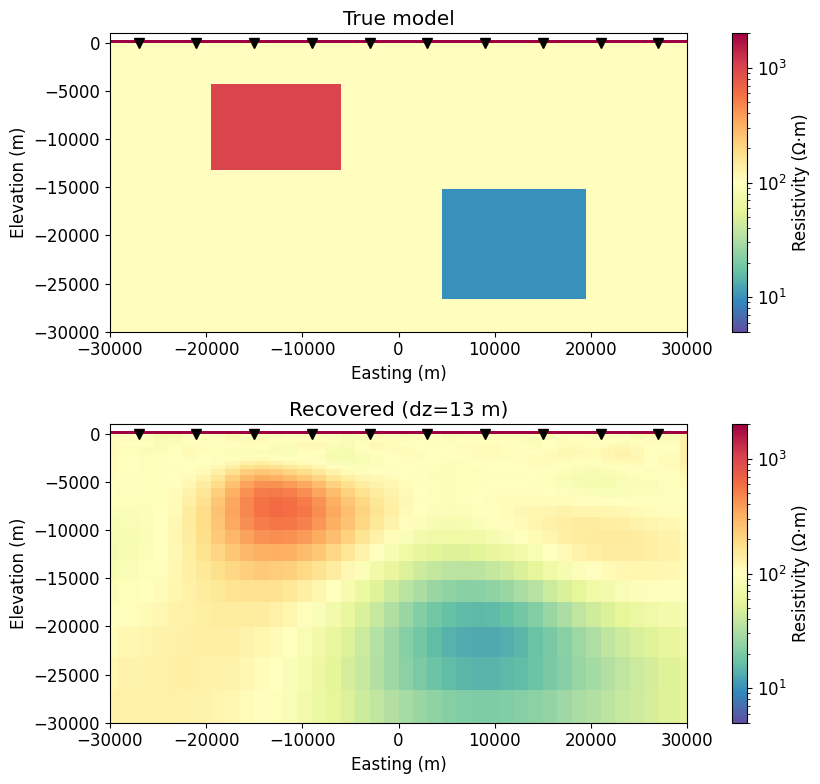

Resistor block : recovered mean   369.0 Ω·m (true 1000)
Conductor block: recovered mean    22.2 Ω·m (true 10)


In [12]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
nrm = LogNorm(vmin=5, vmax=2000)
for ax, r, t in zip(axs, [rho_true, rho_rec], ["True model", f"Recovered (dz={dz_min:.0f} m)"]):
    o = mesh.plot_image(r, ax=ax, grid=False,
        pcolor_opts={"norm": nrm, "cmap": "Spectral_r"},
        range_x=(-30_000, 30_000), range_y=(-30_000, 1_000))
    plt.colorbar(o[0], ax=ax, fraction=0.02, label="Resistivity (Ω·m)")
    ax.plot(rx_locs[:,0], rx_locs[:,1], "kv", ms=7)
    ax.set_aspect(1); ax.set_title(t)
    ax.set_xlabel("Easting (m)"); ax.set_ylabel("Elevation (m)")
plt.tight_layout(); plt.show()

print(f"Resistor block : recovered mean {rho_rec[blk_resistor].mean():7.1f} Ω·m (true 1000)")
print(f"Conductor block: recovered mean {rho_rec[blk_conductor].mean():7.1f} Ω·m (true 10)")

## 8. Why the Finer Mesh Didn't Change the Inversion — *Inverse Crime*

A result worth stating plainly, because it contradicts what you'd reasonably
expect from issue #1: refining the mesh from dz = 50 m to dz = 13 m improves
the **forward** accuracy a lot (11.7% → 2.7% TM error at 400 Hz), but the
recovered model barely moves. Measured directly: near-surface artifact
amplitude was 24.6 Ω·m on the coarse mesh and 23.8 Ω·m on the fine mesh.

The reason is that this notebook — like most synthetic studies — generates the
synthetic data and runs the inversion on the **same mesh**. The 11.7% TM
"error" is then present *identically* in both the observed data and in every
forward call the inversion makes, so it cancels exactly. The inversion never
sees it. This is the classic **inverse crime**.

Two consequences:

1. **The mesh refinement is still worth keeping.** The moment the data come
   from anywhere else — real field data, or synthetic data generated on a
   different mesh — that 11.7% stops cancelling and becomes real, unmodelled
   error that the inversion *will* try to fit as structure.
2. **To test the setup honestly**, generate synthetic data on a fine mesh and
   invert on a coarser, independent one. That is the standard way to avoid
   the inverse crime, and it would make the mesh refinement change the answer.

Two of my initial hypotheses were wrong and worth recording: I first expected
the TM modelling error to be driving the artifacts (it isn't — inverse crime),
and then that raising `alpha_s` would suppress them (it made things far worse,
1148 Ω·m deviation, because it weakens smoothing relative to the total model
norm). The noise-free halfspace test settled it where reasoning did not.

**Also worth knowing:** `directives.UpdateSensitivityWeights` — the usual
remedy for near-surface artifacts — currently **crashes** on 2D NSEM
simulations in SimPEG 0.25.2 with a `getJ` broadcast error
(`operands could not be broadcast together with shapes (3484,10) (34840,)`).
That is a library bug, not a setup issue, so depth weighting isn't available
here without patching SimPEG.